In [1]:
import numpy as np
import polars as pl
from matplotlib import pyplot as plt

In [2]:
def generate_sine(train, val, test, n, seed=42):
    S = train + val + test
    xs = np.linspace(0, 1, 100)[None].repeat(S, 0)
    borders = (2 ** np.arange(1, n + 1)) * 2 * np.pi  # 4pi, 8pi, 16pi

    rng = np.random.default_rng(seed)
    # [4pi, 8pi], [8pi, 16pi] ...
    coeffs = rng.random((S, n)) * borders[None] + borders[None]
    ys = np.sin(coeffs[:, None] * xs[..., None]).sum(-1)
    return (
        pl.DataFrame({"value": ys.tolist(), "time": xs.tolist()})
        .with_row_index()
        .with_columns(
            split=pl.when(pl.col("index") < train)
            .then(pl.lit("train"))
            .when(pl.col("index") < train + val)
            .then(pl.lit("val"))
            .otherwise(pl.lit("test"))
        )
        .drop("index")
    )

In [ ]:
df = generate_sine(32768, 32, 32, n=2)
df.write_parquet("/mnt/data/preprocessed/sine2.parquet")

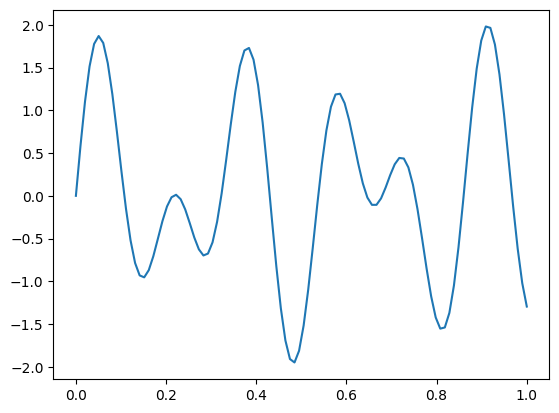

In [4]:
ys, xs = df.row(0)[:2]
plt.plot(xs, ys)
plt.savefig("/app/assets/sine2.pdf")